# LangGraph — Checkpoints, Threads, Human-in-the-Loop

**Что строим:** добавляем персистентность и контроль к HR-агенту из `02_01`.

**Как меняется картина:**
```
invoke(msg, thread_id="A") ──► [checkpoint A₁] ──► ответ
invoke(msg, thread_id="A") ──► [checkpoint A₂] ──► ответ  ← помнит A₁
invoke(msg, thread_id="B") ──► [checkpoint B₁] ──► ответ  ← изолирован
```

**Новые концепции:**
1. `MemorySaver` — in-memory чекпоинтер: сохраняет `state` после каждого узла
2. `thread_id` — ключ разговора: изолирует контексты разных пользователей
3. `get_state` / `get_state_history` — инспекция снимков состояния
4. `interrupt_before` / `interrupt()` — Human-in-the-Loop: пауза и подтверждение
5. `stream()` — наблюдение за шагами в реальном времени
6. `langgraph dev` — визуальный дебаггер в браузере

**Нить прошлого:** тот же HR-граф из `02_01`.

### 0. Setup

In [ ]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
import torch
from typing import TypedDict, Annotated, Literal

from qdrant_client import QdrantClient
from langchain_qdrant import QdrantVectorStore
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_tavily import TavilySearch
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from pydantic import BaseModel
from IPython.display import display, Markdown, Image

/Users/anton/Desktop/total/Elbrus/Elbrus_projects/langgraph_agent/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/anton/Desktop/total/Elbrus/Elbrus_projects/langgraph_agent/.venv/lib/python3.13/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [3]:
COLLECTION_NAME = "vacancies_e5_small_v1"

client = QdrantClient(path="./data/db/vacancies_db")

embeddings_model = HuggingFaceEmbeddings(
    model_name="intfloat/multilingual-e5-small",
    model_kwargs={"device": "mps" if torch.backends.mps.is_available() else "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)

vector_store = QdrantVectorStore(
    client=client,
    collection_name=COLLECTION_NAME,
    embedding=embeddings_model,
)

retriever = vector_store.as_retriever(search_kwargs={"k": 3})

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0, max_tokens=2000)

SALARY_DOMAINS = ["levels.fyi", "glassdoor.com", "career.habr.com", "getmatch.ru", "talent.com"]
tavily = TavilySearch(max_results=3, topic="general")


def format_docs(docs) -> str:
    parts = []
    for i, doc in enumerate(docs, 1):
        m = doc.metadata
        entry = "\n".join([
            f"=== ВАКАНСИЯ {i} ===",
            f"ID: {m.get('id', 'N/A')}",
            f"Должность: {m.get('professional_roles', 'N/A')}",
            f"Компания: {m.get('employer', 'N/A')}",
            f"Скиллы: {', '.join(m.get('extracted_skills', []))}",
            f"Описание: {doc.page_content[:300]}...",
        ])
        parts.append(entry)
    return "\n\n".join(parts)


def parse_tavily(raw, max_chars: int = 1500) -> str:
    if isinstance(raw, str):
        return raw[:max_chars]
    results = raw.get("results", [])
    parts = [f"Source: {r['title']}\n{r['content']}" for r in results]
    return "\n\n".join(parts)[:max_chars]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4678.39it/s]


In [4]:
# Те же компоненты из 02_01 — без изменений

class HRState(TypedDict):
    messages:       Annotated[list, add_messages]
    query_type:     str
    qdrant_results: str
    market_results: str


class QueryClassification(BaseModel):
    query_type: Literal["vacancies", "salary", "both", "smalltalk"]

_classifier_llm = llm.with_structured_output(QueryClassification)


def classify_node(state: HRState) -> dict:
    result = _classifier_llm.invoke([
        SystemMessage(content=(
            "Определи тип запроса:\n"
            "- vacancies  — ищет вакансии или работу\n"
            "- salary     — спрашивает зарплаты или рынок труда\n"
            "- both       — нужны и вакансии, и зарплаты\n"
            "- smalltalk  — не про работу\n"
            "Только схема."
        )),
        HumanMessage(content=state["messages"][-1].content),
    ])
    print(f"  classify → '{result.query_type}'")
    return {"query_type": result.query_type}


def qdrant_node(state: HRState) -> dict:
    docs = retriever.invoke(state["messages"][-1].content)
    results = format_docs(docs)
    print(f"  qdrant   → {len(docs)} вакансий")
    return {"qdrant_results": results}


def market_node(state: HRState) -> dict:
    query = state["messages"][-1].content
    raw = tavily.invoke({"query": query, "include_domains": SALARY_DOMAINS, "search_depth": "basic"})
    results = parse_tavily(raw)
    print(f"  market   → {len(results)} символов")
    return {"market_results": results}


def answer_node(state: HRState) -> dict:
    context_parts = []
    if state.get("qdrant_results"):
        context_parts.append("ВАКАНСИИ:\n" + state["qdrant_results"])
    if state.get("market_results"):
        context_parts.append("РЫНОК ТРУДА:\n" + state["market_results"])

    system_content = "Ты HR-ассистент."
    if context_parts:
        system_content += "\n\nОтвечай на основе контекста:\n\n" + "\n\n".join(context_parts)

    response = llm.invoke([SystemMessage(content=system_content)] + list(state["messages"]))
    return {"messages": [response]}


def route_after_classify(state: HRState) -> str:
    qt = state["query_type"]
    if qt == "salary":    return "market"
    if qt == "smalltalk": return "answer"
    return "qdrant"


def route_after_qdrant(state: HRState) -> str:
    return "market" if state["query_type"] == "both" else "answer"

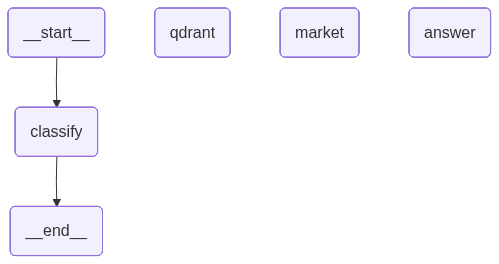

In [5]:
def build_graph(checkpointer=None, interrupt_before=None):
    """Собирает граф. Параметры управляют персистентностью и HITL."""
    g = StateGraph(HRState)
    g.add_node("classify", classify_node)
    g.add_node("qdrant",   qdrant_node)
    g.add_node("market",   market_node)
    g.add_node("answer",   answer_node)
    g.add_edge(START, "classify")
    g.add_conditional_edges("classify", route_after_classify)
    g.add_conditional_edges("qdrant",   route_after_qdrant)
    g.add_edge("market", "answer")
    g.add_edge("answer", END)

    kwargs = {}
    if checkpointer:   kwargs["checkpointer"]   = checkpointer
    if interrupt_before: kwargs["interrupt_before"] = interrupt_before
    return g.compile(**kwargs)


# Базовый граф — без чекпоинтера (как в 02_01)
app = build_graph()
display(Image(app.get_graph().draw_mermaid_png()))

---
### 1. Где мы остановились

В `02_01` каждый `invoke()` **начинает с нуля**:

```
invoke(msg₁) → state₁ → ответ₁  →  ✗ state₁ удалён
invoke(msg₂) → state₂ → ответ₂  →  ✗ state₂ удалён
```

Граф не помнит предыдущих разговоров. Каждый вызов изолирован.

In [6]:
EMPTY = {"query_type": "", "qdrant_results": "", "market_results": ""}

def invoke_stateless(query: str) -> str:
    result = app.invoke({"messages": [HumanMessage(content=query)], **EMPTY})
    return result["messages"][-1].content

r1 = invoke_stateless("Найди вакансии Data Scientist")
r2 = invoke_stateless("А что насчёт зарплат у DS?")  # ← не знает про r1

print("Turn 1:", r1[:120], "...")
print()
print("Turn 2:", r2[:120], "...")
print()
print("Проблема: turn 2 не видит историю turn 1 — каждый invoke изолирован.")

  classify → 'vacancies'
  qdrant   → 3 вакансий
  classify → 'salary'
  market   → 552 символов
Turn 1: Найдены две вакансии Data Scientist:

1. **Вакансия 1**: Программист, разработчик (Data Scientist) в компании "Лига Цифр ...

Turn 2: Зарплаты у Data Scientist (DS) могут варьироваться в зависимости от компании, опыта и местоположения. Однако, исходя из  ...

Проблема: turn 2 не видит историю turn 1 — каждый invoke изолирован.


---
### 2. Checkpoints — персистентность состояния

**Чекпоинтер** — хранилище снимков `state`. LangGraph сохраняет состояние после каждого узла.

```
classify → [ck₁] → qdrant → [ck₂] → answer → [ck₃]
```

Ключ разговора: `thread_id` в конфиге. Два вызова с одним `thread_id` = один разговор.

| Чекпоинтер | Хранилище | Когда |
|---|---|---|
| `MemorySaver` | оперативная память | разработка, тесты |
| `SqliteSaver` | SQLite-файл | локальный прод |
| `PostgresSaver` | PostgreSQL | продакшн |

In [ ]:
memory = MemorySaver()
app_mem = build_graph(checkpointer=memory)

# thread_id — уникальный ключ разговора
THREAD_A = {"configurable": {"thread_id": "user-alice"}}

In [ ]:
# Первая реплика Алисы
result1 = app_mem.invoke(
    {"messages": [HumanMessage(content="Найди вакансии Data Scientist")], **EMPTY},
    config=THREAD_A,
)
display(Markdown(f"**Turn 1 →** {result1['messages'][-1].content[:300]}..."))

In [ ]:
# Вторая реплика — передаём только НОВОЕ сообщение, история в чекпоинте
result2 = app_mem.invoke(
    {"messages": [HumanMessage(content="А какие зарплаты у Data Scientist?")]},
    config=THREAD_A,
)
display(Markdown(f"**Turn 2 →** {result2['messages'][-1].content[:300]}..."))
print(f"\nСообщений в истории треда: {len(result2['messages'])}")
# ↑ должно быть 4: HumanMsg₁ + AIMsg₁ + HumanMsg₂ + AIMsg₂

---
### 3. Threads — изолированные контексты

`thread_id` — **ключ изоляции**: разные пользователи не видят чужих данных.

```
Thread "user-alice" ──► history_alice: [msg₁, msg₂, msg₃, ...]
Thread "user-bob"   ──► history_bob:  [msg₁, msg₂, ...]  ← полностью отдельно
```

`get_state(config)` — снимок текущего состояния треда
`get_state_history(config)` — все чекпоинты треда (от новых к старым)

In [ ]:
THREAD_B = {"configurable": {"thread_id": "user-bob"}}

# Боб спрашивает про другое — изолированный контекст
app_mem.invoke(
    {"messages": [HumanMessage(content="Есть вакансии backend-разработчика?")], **EMPTY},
    config=THREAD_B,
)

# Алиса и Боб — разные изолированные треды
state_alice = app_mem.get_state(THREAD_A)
state_bob   = app_mem.get_state(THREAD_B)

print(f"Alice — сообщений в истории: {len(state_alice.values['messages'])}")
print(f"Bob   — сообщений в истории: {len(state_bob.values['messages'])}")
print(f"Alice query_type: {state_alice.values['query_type']}")
print(f"Bob   query_type: {state_bob.values['query_type']}")

In [ ]:
# История всех чекпоинтов треда Алисы (от новых к старым)
history = list(app_mem.get_state_history(THREAD_A))
print(f"Чекпоинтов в треде Alice: {len(history)}")
print()

for snap in history[:6]:
    next_nodes = snap.next or ("END",)
    step = snap.metadata.get("step", "?")
    msgs = len(snap.values["messages"])
    print(f"  step={step:>2}  next={next_nodes}  msgs={msgs}")

---
### 4. Runs — потоковое наблюдение

**Run** — один запуск графа (`invoke` или `stream`).

`stream()` отдаёт события по мере выполнения — не ждёт финала.

| `stream_mode` | Что приходит |
|---|---|
| `"values"` | полный `state` после каждого узла |
| `"updates"` | `{node_name: изменения}` — только дельта |
| `"debug"` | все внутренние события (чекпоинты, метаданные) |

In [ ]:
print("Наблюдаем за шагами в реальном времени:\n")

for chunk in app_mem.stream(
    {"messages": [HumanMessage(content="Найди вакансии ML-инженера в финтехе и зарплаты")], **EMPTY},
    config={"configurable": {"thread_id": "stream-demo"}},
    stream_mode="updates",
):
    node_name = list(chunk.keys())[0]
    updates   = chunk[node_name]

    if "query_type" in updates:
        print(f"  [{node_name}] query_type = '{updates['query_type']}'")
    elif "qdrant_results" in updates:
        print(f"  [{node_name}] qdrant_results = {len(updates['qdrant_results'])} символов")
    elif "market_results" in updates:
        print(f"  [{node_name}] market_results = {len(updates['market_results'])} символов")
    elif "messages" in updates:
        print(f"  [{node_name}] answer = {len(updates['messages'][-1].content)} символов")

---
### 5. Human-in-the-Loop

**Задача:** перед запуском дорогого или рискованного узла — спросить человека.

**Два механизма:**

**1. `interrupt_before` в `compile()`** — автоматическая пауза перед узлом:
```python
app = graph.compile(checkpointer=memory, interrupt_before=["market"])
```

**2. `interrupt()` внутри узла** — нода сама решает когда остановиться:
```python
from langgraph.types import interrupt, Command

def market_node_v2(state):
    decision = interrupt("Запустить поиск рынка? (yes/no)")  # ← пауза здесь
    if decision == "no":
        return {"market_results": ""}
    ...
```

В обоих случаях состояние сохраняется в чекпоинт.
Возобновление: `invoke(None, config)` или `invoke(Command(resume=value), config)`.

In [ ]:
# Компилируем с паузой перед market_node
app_hitl = build_graph(
    checkpointer=MemorySaver(),
    interrupt_before=["market"],
)

HITL_THREAD = {"configurable": {"thread_id": "hitl-demo"}}

In [ ]:
print("Запускаем граф — ожидаем паузу перед market...\n")

# Запрос типа "both" → classify → qdrant → [ПАУЗА] → market → answer
state_at_pause = app_hitl.invoke(
    {"messages": [HumanMessage(content="Найди вакансии DS в финтехе и расскажи про зарплаты")], **EMPTY},
    config=HITL_THREAD,
)

# Что происходит после паузы
snapshot = app_hitl.get_state(HITL_THREAD)
print(f"Следующий узел (ожидает): {snapshot.next}")
print(f"query_type:     {snapshot.values['query_type']}")
print(f"qdrant_results: {len(snapshot.values['qdrant_results'])} символов (уже есть)")
print(f"market_results: '{snapshot.values['market_results']}' (ещё пустой)")
print()
print("Граф паузит, ждёт решения человека.")

На этом шаге граф остановлен. Можно:
- **Продолжить:** `invoke(None, config)` → запустит `market_node`
- **Пропустить:** `update_state(config, {"market_results": "нет данных"}, as_node="market")` + `invoke(None, config)`
- **Изменить запрос:** `update_state(config, {"messages": [...]})` — правка до возобновления

In [ ]:
# Человек одобрил — продолжаем с того же места
print("Продолжаем граф...\n")

final = app_hitl.invoke(None, config=HITL_THREAD)
display(Markdown(final["messages"][-1].content[:500] + "..."))

In [ ]:
# Альтернатива: update_state + resume
# Полезно когда человек хочет изменить данные перед продолжением

HITL_THREAD2 = {"configurable": {"thread_id": "hitl-update-demo"}}

app_hitl.invoke(
    {"messages": [HumanMessage(content="Вакансии аналитика данных и зарплаты")], **EMPTY},
    config=HITL_THREAD2,
)

# Граф паузит — человек решает вставить свои данные рынка
app_hitl.update_state(
    HITL_THREAD2,
    {"market_results": "Аналитик данных: junior 80–120k, middle 150–200k, senior 250k+"},
    as_node="market",  # ← притворяемся, что market_node уже отработал
)

# Возобновляем — market пропускается, answer видит наши данные
final2 = app_hitl.invoke(None, config=HITL_THREAD2)
display(Markdown(final2["messages"][-1].content[:500] + "..."))

In [ ]:
# interrupt() внутри ноды — нода сама управляет паузой

def market_node_with_approval(state: HRState) -> dict:
    query = state["messages"][-1].content

    # Граф паузит здесь, возвращает словарь вызывающему коду
    decision = interrupt({
        "question": "Запустить поиск рынка труда?",
        "query": query[:80],
    })

    if decision == "no":
        return {"market_results": "Поиск отменён пользователем"}

    raw = tavily.invoke({"query": query, "include_domains": SALARY_DOMAINS, "search_depth": "basic"})
    return {"market_results": parse_tavily(raw)}


def build_approval_graph():
    g = StateGraph(HRState)
    g.add_node("classify", classify_node)
    g.add_node("qdrant",   qdrant_node)
    g.add_node("market",   market_node_with_approval)
    g.add_node("answer",   answer_node)
    g.add_edge(START, "classify")
    g.add_conditional_edges("classify", route_after_classify)
    g.add_conditional_edges("qdrant",   route_after_qdrant)
    g.add_edge("market", "answer")
    g.add_edge("answer", END)
    return g.compile(checkpointer=MemorySaver())

app_approval = build_approval_graph()
APPROVAL_THREAD = {"configurable": {"thread_id": "approval-demo"}}

In [ ]:
# Запускаем — граф паузит внутри market_node при вызове interrupt()
app_approval.invoke(
    {"messages": [HumanMessage(content="Вакансии DS и зарплаты в финтехе")], **EMPTY},
    config=APPROVAL_THREAD,
)

snap = app_approval.get_state(APPROVAL_THREAD)
print(f"Граф паузит, следующий: {snap.next}")

# Задаём значение через interrupt():
interrupt_data = snap.tasks[0].interrupts[0].value
print(f"Вопрос от графа: {interrupt_data}")
print()

# Человек отвечает "yes" — возобновляем с Command(resume=...)
final_approval = app_approval.invoke(Command(resume="yes"), config=APPROVAL_THREAD)
display(Markdown(final_approval["messages"][-1].content[:500] + "..."))

---
### 6. LangGraph dev — визуальный дебаггер

`langgraph dev` поднимает локальный сервер, подключённый к **LangGraph Studio** в браузере.

**Что даёт Studio:**
- **Graph** — интерактивная схема, подсветка активного узла в реальном времени
- **Threads** — список разговоров, история чекпоинтов каждого треда
- **State** — инспекция и прямое редактирование полей состояния
- **HITL** — кнопка «Continue» вместо `invoke(None, config)`, форма для `Command(resume=...)`
- **Runs** — логи каждого запуска с временными метками

**Требования:**
```bash
pip install langgraph-cli[inmem]  # или через uv add
```

**Конфиг `langgraph.json`** — нужен в корне проекта.

In [ ]:
import json, pathlib

config = {
    "dependencies": ["."],
    "graphs": {
        "hr_agent_v2": "./src/graph.py:app"   # имя_в_studio: путь:переменная
    },
    "env": ".env"
}

cfg_path = pathlib.Path("langgraph.json")
with open(cfg_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("Создан langgraph.json:")
print(json.dumps(config, indent=2, ensure_ascii=False))

После создания `langgraph.json` запускаем в терминале из корня проекта:

```bash
langgraph dev
# или с явным портом:
langgraph dev --port 2024
```

В терминале появится:
```
🚀 LangGraph API server is running at http://localhost:2024
```

Браузер откроет **LangGraph Studio** → вкладка **Graphs** → `hr_agent_v2`.

> **Совет:** в `src/graph.py` замени `MemorySaver()` на `SqliteSaver("./data/db/checkpoints.db")`
> чтобы треды сохранялись между перезапусками сервера.

In [ ]:
client.close()